In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:

!pip install flowio

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for flowio: filename=flowio-1.4.0-py3-none-any.whl size=21897 sha256=b77381a6ae97b26492f2920a0c383b7f3ee2c05bfacdb0ce3a3e9588f2acebbf
  Stored in directory: /root/.cache/pip/wheels/85/ac/b0/1e3bf1774da784e601a026a80622d0a25979d52ef416c0e027
Successfully built flowio


In [4]:
import shutil
import pandas as pd
import random

import copy
import numpy as np # Import numpy for checking finite values
import matplotlib.pyplot as plt # Import matplotlib for potential debugging

import os
import math # Import math for ceil
from sklearn.manifold import TSNE # Import TSNE to check default perplexity

PYTHONHASHSEED = '42'
TF_DETERMINISTIC_OPS = '1'
TF_CUDNN_DETERMINISTIC = '1'
os.environ['PYTHONHASHSEED'] = '42'
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'  # For CuDNN ops

import glob
import json
import tensorflow as tf
import sys
from itertools import zip_longest

from sklearn import metrics
import pickle
import time
import csv
import traceback
import gc


from sklearn.metrics import f1_score
from sklearn.metrics import recall_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score

In [5]:

#fixed_path = 'C:\\Users\\Enrico Didoli\\0.Master_Thesis\\'
#fixed_path = 'C:\\Users\\admin\\0.Master_Thesis\\'
fixed_path = '/content/drive/MyDrive/0.Master_Thesis/'

if fixed_path not in sys.path:
    sys.path.append(fixed_path)

old_cellcnn_path = f'{fixed_path}CellCNN/Ubuntu/Old_CellCNN/old_cellCnn/'
if old_cellcnn_path not in sys.path:
    sys.path.append(old_cellcnn_path)

cellcnn_path = f'{fixed_path}CellCNN/Ubuntu/'
if cellcnn_path not in sys.path:
    sys.path.append(cellcnn_path)

general_functions_path = f'{fixed_path}General_Functions/'
if general_functions_path not in sys.path:
    sys.path.append(general_functions_path)

save_path = f'{fixed_path}CellCNN/Ubuntu/results/'
if save_path not in sys.path:
    sys.path.append(save_path)

other_functions_path = f'{cellcnn_path}New running ipynb/Final_notebooks/modules/'
if other_functions_path not in sys.path:
    sys.path.append(other_functions_path)


In [6]:
decache_files = ['timepoints_elaboration', 'results_elaboration', 'new_datasets_generation', 'run_models',
                 'model', 'utils', 'downsample', 'model_grid',
                'All_fixed_functions', 'functions']

# Rimuovi il modulo specifico dalla cache
from timepoints_elaboration import remove_from_cache
remove_from_cache(decache_files)

# import downloaded modules
from model_grid import CellCnn

import utils as utils
import downsample as downsample

from timepoints_elaboration import load_data, donation_extraction, dataset_elaboration
from timepoints_elaboration import donor_division, patient_code_extraction, remove_from_cache

from results_elaboration import extract_hyper, phenotype_prediction, default_serializer, show_hyperparameters
from results_elaboration import elaborate_predictions, show_hyper


from run_models import  trials_train_CellCNN_old, trials_test_CellCNN_old

from new_datasets_generation import splitting_and_dataset_elaboration

from functions import remove_labels, show_blast_distribution_perc, train_val_finalizing, prepare_results_to_save, retrieve_labels
from functions import subset_sampling, flatten, generate_LOPOCV_dicts, generate_LOPOCV_folds, extract_fold_features, val_res_pred
from functions import find_robust_threshold, test_res_pred, generate_seeds, run_training, save_models, nsub_ncells_comb, find_theta_best



timepoints_elaboration rimosso dalla cache
results_elaboration non trovato nella cache
new_datasets_generation non trovato nella cache
run_models non trovato nella cache
model non trovato nella cache
utils non trovato nella cache
downsample non trovato nella cache
model_grid non trovato nella cache
All_fixed_functions non trovato nella cache
functions non trovato nella cache


In [7]:

def load_models(model, meta):
        model = CellCnn()

        model.scale = meta['scale']
        model.quant_normed = meta['quant_normed']
        model.regression = meta['regression']
        model.nsubset = meta['nsubset']
        model.ncell = meta['ncell']
        model.per_sample = meta['per_sample']
        model.subset_selection = meta['subset_selection']
        model.maxpool_percentages = meta['maxpool_percentages']
        model.nfilter_choice = meta['nfilter_choice']
        model.learning_rate = meta['learning_rate']
        model.coeff_l1 = meta['coeff_l1']
        model.coeff_l2 = meta['coeff_l2']
        model.dropout = meta['dropout']
        model.dropout_p = meta['dropout_p']
        model.max_epochs = meta['max_epochs']
        model.patience = meta['patience']
        model.dendrogram_cutoff = meta['dendrogram_cutoff']
        model.accur_thres = meta['accur_thres']
        model.verbose = meta['verbose']
        model.resampled = meta['resampled']
        model.seed = meta['seed']
        model.results = meta['results']
        model.grid = meta['grid']

        return model

In [8]:


def get_actual_size(obj):
    """Get TRUE memory size"""
    if isinstance(obj, pd.DataFrame):
        return obj.memory_usage(deep=True).sum()
    elif isinstance(obj, pd.Series):
        return obj.memory_usage(deep=True)
    elif isinstance(obj, np.ndarray):
        return obj.nbytes
    elif isinstance(obj, (list, tuple, set, dict)):
        # For containers, sum up contents
        return sys.getsizeof(obj) + sum(sys.getsizeof(item) for item in obj)
    else:
        return sys.getsizeof(obj)

def print_var_memory(var_to_check = None):
    # Display all variables with ACTUAL sizes
    all_vars = %who_ls
    sizes = []
    if var_to_check is None:
        var_to_check = all_vars


    for var_name in all_vars:
        #try:
            var = eval(var_name)

            #if var_name in  ('train_datasets_extracted','val_datasets_extracted','test_datasets_extracted'):
            if var_name in var_to_check:
                #print(var)
                if isinstance(var, (list, tuple)):
                    var = flatten(var)
                    tot = 0
                    for element in var:
                        tot += get_actual_size(element)
                    size = tot
                    sizes.append((var_name, type(var).__name__, size))
            else:
                size = get_actual_size(var)
                sizes.append((var_name, type(var).__name__, size))

        #except:
        #    pass

    # Sort by size
    sizes.sort(key=lambda x: x[2], reverse=True)

    # Pretty print
    print(f"{'Variable':<25} {'Type':<20} {'Memory':>15}")
    print("-" * 65)
    total = 0
    var_to_check = []
    for name, type_name, size in sizes:
        total += size
        if size > 1024**3:  # GB
            print(f"{name:<25} {type_name:<20} {size/(1024**3):>12.2f} GB")
            var_to_check.append(name)

        elif size > 1024**2:  # MB
            print(f"{name:<25} {type_name:<20} {size/(1024**2):>12.2f} MB")
            var_to_check.append(name)
        '''
        elif size > 1024:  # KB
            print(f"{name:<25} {type_name:<20} {size/1024:>12.2f} KB")

        else:
            print(f"{name:<25} {type_name:<20} {size:>12} bytes")
        '''
    print("-" * 65)
    print(f"{'TOTAL':<25} {'':<20} {total/(1024**3):>12.2f} GB")
    return var_to_check

print_var_memory()

Variable                  Type                          Memory
-----------------------------------------------------------------
-----------------------------------------------------------------
TOTAL                                                  0.00 GB


[]

# code

In [9]:

tuning_exp = 'Trial_5_fix_code_NO_AS_bayesian_tuning'


config_save_dir = f'{cellcnn_path}/experiments/experiment_{tuning_exp}/'
os.makedirs(config_save_dir, exist_ok=True)

with open(os.path.join(config_save_dir, 'config.pkl'), 'rb') as f:
            config = pickle.load(f)

'''
PYTHONHASHSEED = config['PYTHONHASHSEED']
TF_DETERMINISTIC_OPS = config['TF_DETERMINISTIC_OPS']
TF_CUDNN_DETERMINISTIC = config['TF_CUDNN_DETERMINISTIC']
'''

starting_seed = config['starting_seed']
n_sub = config['n_sub ']
n_cells = config['n_cells']
blast_perc = config['blast_perc']
nfilter = config['nfilter']
maxpool_p = config['maxpool_p']
learning_r = config['learning_r']
labels = config['labels'] # if False internal data augmentation do not takes in account true subset condition

hyper = (nfilter, maxpool_p, learning_r)

print(starting_seed)
print(n_sub)
print(n_cells)
print(blast_perc)
print(nfilter)
print(maxpool_p)
print(learning_r)
print(labels)


1000
3
100000
[0.0001, 0.001, 0.01]
[5, 7, 9]
[0.01, 1, 10, 100]
[0.001, 0.005]
False


In [10]:
%%time

# Trova tutti i file con estensione specifica in una cartella
data_folder = f'{fixed_path}B-ALL_Datasets'
extension = '*.csv'  # cambia con l'estensione che ti serve

multiple_donations, ALL_DATASETS = load_data(data_path = data_folder, ext = extension)#, remove_control = True)



0.09
Elaborating file 0: /content/drive/MyDrive/0.Master_Thesis/B-ALL_Datasets/B-ALL_expression_matrix_B-ALL_GHE1_D15_2.csv
0.0
Elaborating file 1: /content/drive/MyDrive/0.Master_Thesis/B-ALL_Datasets/B-ALL_expression_matrix_B-ALL_GHE1_D78.csv
0.16
Elaborating file 2: /content/drive/MyDrive/0.Master_Thesis/B-ALL_Datasets/B-ALL_expression_matrix_B-ALL_GHE11_D15_1.csv
0.01
Elaborating file 3: /content/drive/MyDrive/0.Master_Thesis/B-ALL_Datasets/B-ALL_expression_matrix_B-ALL_GHE11_D29_1.csv
0.0
Elaborating file 4: /content/drive/MyDrive/0.Master_Thesis/B-ALL_Datasets/B-ALL_expression_matrix_B-ALL_GHE11_D71_1.csv
0.15
Elaborating file 5: /content/drive/MyDrive/0.Master_Thesis/B-ALL_Datasets/B-ALL_expression_matrix_B-ALL_GHE12_D15_2.csv
0.0
Elaborating file 6: /content/drive/MyDrive/0.Master_Thesis/B-ALL_Datasets/B-ALL_expression_matrix_B-ALL_GHE12_D29_1.csv
39.56
Elaborating file 7: /content/drive/MyDrive/0.Master_Thesis/B-ALL_Datasets/B-ALL_expression_matrix_B-ALL_GHE2_D15_2.csv
15.06
E

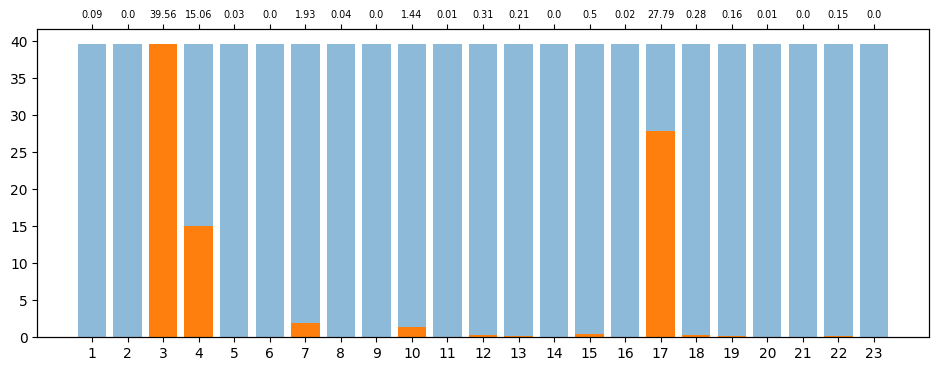

[np.float64(0.09), np.float64(0.0), np.float64(39.56), np.float64(15.06), np.float64(0.03), np.float64(0.0), np.float64(1.93), np.float64(0.04), np.float64(0.0), np.float64(1.44), np.float64(0.01), np.float64(0.31), np.float64(0.21), np.float64(0.0), np.float64(0.5), np.float64(0.02), np.float64(27.79), np.float64(0.28), np.float64(0.16), np.float64(0.01), np.float64(0.0), np.float64(0.15), np.float64(0.0)]


In [11]:

tot_perc_list = show_blast_distribution_perc(ALL_DATASETS, multiple_donations, return_perc = True)
print(tot_perc_list)

In [12]:

full_LOPOCV_dicts = generate_LOPOCV_dicts(multiple_donations, ALL_DATASETS)
LOPOCV_patients_folds = generate_LOPOCV_folds(full_LOPOCV_dicts, ALL_DATASETS, starting_seed)

dict_keys(['2', '3', '4', '6', '7', '8', '9', '11', '12']) dict_keys(['1']) [np.float64(0.08762), np.float64(0.0)]
dict_keys(['1', '3', '4', '6', '7', '8', '9', '11', '12']) dict_keys(['2']) [np.float64(39.55814), np.float64(15.0633)]
dict_keys(['1', '2', '4', '6', '7', '8', '9', '11', '12']) dict_keys(['3']) [np.float64(0.03462), np.float64(0.0)]
dict_keys(['1', '2', '3', '6', '7', '8', '9', '11', '12']) dict_keys(['4']) [np.float64(1.92897), np.float64(0.04035), np.float64(0.0)]
dict_keys(['1', '2', '3', '4', '7', '8', '9', '11', '12']) dict_keys(['6']) [np.float64(1.43503), np.float64(0.00775)]
dict_keys(['1', '2', '3', '4', '6', '8', '9', '11', '12']) dict_keys(['7']) [np.float64(0.31479), np.float64(0.20732), np.float64(0.0)]
dict_keys(['1', '2', '3', '4', '6', '7', '9', '11', '12']) dict_keys(['8']) [np.float64(0.49896), np.float64(0.01692)]
dict_keys(['1', '2', '3', '4', '6', '7', '8', '11', '12']) dict_keys(['9']) [np.float64(27.7918), np.float64(0.2798)]
dict_keys(['1', '2', '

# ncells and nsub bayesian tuning

In [13]:
%%time

start_lopocv_fold = 0
end_lopocv_fold = 0

exp = 'Trial_5_fix_code_NO_AS_single_split'

save_memory = False # set True to save RAM memory
grid = True


weights_outdir = f'{config_save_dir}/weights'
os.makedirs(weights_outdir, exist_ok=True)
full_process_time_list = []

for LOPOCV_fold_idx, (train_kfolds, test_pat) in enumerate(LOPOCV_patients_folds): # for each LOPO fold
  if LOPOCV_fold_idx >= start_lopocv_fold:

        LOPOCV_start = time.time()

        # === Import Base seed === #
        seed_load_dir = f'{cellcnn_path}/experiments/experiment_{tuning_exp}/outer_fold_{LOPOCV_fold_idx}/'

        with open(os.path.join(seed_load_dir, 'tuning_seed_info.pkl'), 'rb') as f:
                            seed_info = pickle.load(f)

        print('check seeds:', seed_info)
        training_split_seed = seed_info['final_tuning_base_seed']
        fold_base_seed = seed_info['fold_base_seed']

        base_seed = fold_base_seed
        np.random.seed(training_split_seed)

        # === Import Tuned theta* and BO thresholds === #
        tuning_load_dir = f'{cellcnn_path}/experiments/experiment_{tuning_exp}/outer_fold_{LOPOCV_fold_idx}/tuning/results'

        with open(os.path.join(tuning_load_dir, 'best_ncells.pkl'), 'rb') as f:
                            best_ncells = pickle.load(f)

        with open(os.path.join(tuning_load_dir, 'best_nsub.pkl'), 'rb') as f:
                            best_nsub = pickle.load(f)

        with open(os.path.join(tuning_load_dir, 'robust_threshold.pkl'), 'rb') as f:
                            robust_threshold = pickle.load(f)

        with open(os.path.join(tuning_load_dir, 'roc_threshold.pkl'), 'rb') as f:
                            roc_threshold = pickle.load(f)

        print(f'Theta*: {best_ncells, best_nsub}')
        print(f'ROC threshold: {roc_threshold}')
        print(f'RES threshold: {robust_threshold}')


        # === Generate Training and Validation Set === #

        train_val_patients = np.concatenate(train_kfolds[0]) # full set of patients idx
        np.random.shuffle(train_val_patients)
        n_val = max( int(round(0.2*len(train_val_patients))) ,1)
        train_donors_idx = train_val_patients[n_val:]
        val_donors_idx = train_val_patients[:n_val]

        print(f'Train patients: {train_donors_idx}')
        print(f'Validation patients: {val_donors_idx}')
        print(f'Test patient: {test_pat}')


        if save_memory:
            if LOPOCV_fold_idx != start_lopocv_fold:
                multiple_donations, ALL_DATASETS = load_data(data_path = data_folder, ext = extension)

        # === Extracts Samples for Train and Validation === #

        # extraxt samples using pre-splitted indexes
        train_datasets_extracted = donation_extraction(train_donors_idx, multiple_donations, ALL_DATASETS)
        val_datasets_extracted = donation_extraction(val_donors_idx, multiple_donations, ALL_DATASETS)
        test_datasets_extracted = donation_extraction(test_pat, multiple_donations, ALL_DATASETS)

        # first 30k seeds for tuning
        base_seed += 30000  #20k for AS generation
        base_final_training_AS_seed = base_seed


        try:
            # remove cell-level labels and retrive sample labels
            original_train_datasets, original_train_y = retrieve_labels(train_datasets_extracted, remove = True, flat = True)
            original_val_datasets, original_val_y = retrieve_labels(val_datasets_extracted, remove = True, flat = True)

            if save_memory:
                del ALL_DATASETS
                gc.collect()

            trials = 2 ### 5  # number of weights initializations

            # === Generate seed lists in advance === #

            train_CV_seed = base_seed + 1000
            seed_list = generate_seeds(len(LOPOCV_patients_folds)*2, seed = train_CV_seed)

            pred_CV_seed = base_seed + 2000
            tuning_prediction_seed_list = generate_seeds(trials, seed = pred_CV_seed)

            base_seed += 200
            final_orig_pred_seed = base_seed
            original_prediction_seed_list = generate_seeds(trials, seed = final_orig_pred_seed)

            base_seed += 1000
            final_rob_pred_seed = base_seed
            robust_prediction_seed_list = generate_seeds(3, seed = final_rob_pred_seed)


            # === Train Models === #

            models_lists = run_training(CellCnn, original_train_datasets, original_train_y,
                                                new_val_datasets = original_val_datasets,
                                                new_val_y = original_val_y,
                                                new_test_datasets = None,
                                                seed_list =  seed_list, hyper = hyper, grid = grid, labels = labels,
                                                trials = trials,
                                                cells_per_sub = best_ncells, ## Tuned ncells ##
                                                best_nsub = best_nsub,        ## Tuned nsub   ##
                                                max_epochs = 1,              ### 100,
                                                nrun = None,                  #grid search, so doesn't matter wht number
                                                generate = False)


            # save models
            for i, model in enumerate(models_lists):
                        save_models_dir = f'{cellcnn_path}/experiments/experiment_{exp}/outer_fold_{LOPOCV_fold_idx}/training/models/seed_{i}'
                        os.makedirs(save_models_dir, exist_ok=True)
                        save_models(model, save_models_dir)

            for i in range(1):

                        # === Prediction Approach: CellCNN with tau = 0.5 === #

                        if save_memory:
                            print('Load data for Test set')
                            multiple_donations, ALL_DATASETS = load_data(data_path = data_folder, ext = extension)

                        test_datasets_extracted = donation_extraction(test_pat, multiple_donations, ALL_DATASETS)

                        if save_memory:
                            del ALL_DATASETS

                        original_test_datasets, original_test_y = retrieve_labels(test_datasets_extracted, remove = True, flat = True)
                        print(f'Ground thruth labels: {original_test_y}')

                        # Test set prediction
                        original_predictions_list, original_results_list = trials_test_CellCNN_old(models_lists, original_test_datasets, original_prediction_seed_list)

                        print('Save Direct Prediction results')
                        save_original_dir = f'{cellcnn_path}/experiments/experiment_{exp}/outer_fold_{LOPOCV_fold_idx}/results/direct'

                        os.makedirs(save_original_dir, exist_ok=True)

                        with open(os.path.join(save_original_dir, 'original_predictions_list.pkl'), 'wb') as f:
                                        pickle.dump(original_predictions_list, f)
                        with open(os.path.join(save_original_dir, 'original_results_list.pkl'), 'wb') as f:
                                        pickle.dump(original_results_list, f)
                        with open(os.path.join(save_original_dir, 'original_test_y.pkl'), 'wb') as f:
                                        pickle.dump(original_test_y, f)



                        # === Prediction Approach: Resamplimg === #

                        print('Start Robust prediction using ROC threshold')

                        test_resample_n = 100000 #same dimension of AS
                        k = 2 ### 50


                        per_donor_original_test_datasets, per_donor_original_test_y = retrieve_labels(test_datasets_extracted, remove = False)
                        print(f'Ground thruth labels per patient: {per_donor_original_test_y}')

                        # Test set prediction
                        (_, #test_total_labels,               # Predicted resampled subsets labels
                            test_total_pred_lists,           # Mean predictions of resampled subsets across trials (per patient)
                            test_total_trial_pred_lists,     # Lists of trial predictions of resampled subsets (per patient)
                            per_donor_resampled_test_y       # True labels of resampled subsets (per patient)
                                                    ) = test_res_pred(
                                                        models_lists,
                                                        per_donor_original_test_datasets,
                                                        test_resample_n,
                                                        k,
                                                        roc_threshold, # doesn't matter which theshold we use. We save only the predictions becfore classification
                                                        trials,
                                                        seed = robust_prediction_seed_list[1])


                        save_robust_dir = f'{cellcnn_path}/experiments/experiment_{exp}/outer_fold_{LOPOCV_fold_idx}/results/robust/roc'
                        os.makedirs(save_robust_dir, exist_ok=True)

                        with open(os.path.join(save_robust_dir, 'test_total_trial_pred_lists.pkl'), 'wb') as f:
                                        pickle.dump(test_total_trial_pred_lists, f)
                        with open(os.path.join(save_robust_dir, 'per_donor_resampled_test_y.pkl'), 'wb') as f:
                                        pickle.dump(per_donor_resampled_test_y, f)
                        with open(os.path.join(save_robust_dir, 'per_donor_original_test_y.pkl'), 'wb') as f:
                                        pickle.dump(per_donor_original_test_y, f)


        except Exception as e:
                        print(f"Training error: {e}")
                        traceback.print_exc()

        fold_end = time.time()
        print('')
        print(f'Time elapsed from start LOPOCV iteration: {LOPOCV_start - fold_end}')
        print('')

        #save seeds outside the ensemble
        tuning_save_dir = f'{cellcnn_path}/experiments/experiment_{exp}/outer_fold_{LOPOCV_fold_idx}/'
        os.makedirs(tuning_save_dir, exist_ok=True)


        with open(os.path.join(tuning_save_dir, 'seed_info.pkl'), 'wb') as f:
                                pickle.dump({
                                    'starting_seed': starting_seed,
                                    'LOPOCV_fold_idx': LOPOCV_fold_idx,
                                    'fold_base_seed': fold_base_seed,
                                    'base_final_training_AS_seed': base_final_training_AS_seed,
                                    'training_split_seed': training_split_seed,
                                    'final_base_seed': base_seed
                                }, f)

        elapsed_time_for_LOPOCV = time.time() - LOPOCV_start
        print(f'elapsed_time_for_LOPOCV fold {LOPOCV_fold_idx}: {elapsed_time_for_LOPOCV}')

        with open(os.path.join(tuning_save_dir, 'elapsed_time_for_LOPOCV.pkl'), 'wb') as f:
                                pickle.dump(elapsed_time_for_LOPOCV, f)

        if LOPOCV_fold_idx >= end_lopocv_fold:
            break


check seeds: {'starting_seed': 1000, 'LOPOCV_fold_idx': 0, 'fold_base_seed': 1000, 'final_tuning_base_seed': 12510}
Theta*: (100, 450)
ROC threshold: 0.6701063911120096
RES threshold: 0.006500000000000001
Train patients: ['3' '11' '8' '12' '6' '9' '4']
Validation patients: ['7' '2']
Test patient: ['1']
5
16
Labels from Train and Validations Sets have been REMOVED.
Grid Search Ready!
0
Trial 1 started
Seed used: 6879
Seed used: 6879: <class 'numpy.int64'>
Model defined...
Fitting started...
No labels detected. "labels" variable set to False
Start generating subsets elabortating samples WITHOUT label column
Number of training subsets generated: 11
Number of validation subsets generated: 11
(5, 0.01, 0.001)
(5, 0.01, 0.005)
(5, 1, 0.001)
(5, 1, 0.005)
(5, 10, 0.001)
(5, 10, 0.005)
(5, 100, 0.001)
(5, 100, 0.005)
(7, 0.01, 0.001)
(7, 0.01, 0.005)
(7, 1, 0.001)
(7, 1, 0.005)
(7, 10, 0.001)
(7, 10, 0.005)
(7, 100, 0.001)
(7, 100, 0.005)
(9, 0.01, 0.001)
(9, 0.01, 0.005)
(9, 1, 0.001)
(9, 1, 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


Trial 2 started
Seed used: 257332
Seed used: 257332: <class 'numpy.int64'>
Model defined...
Fitting started...
No labels detected. "labels" variable set to False
Start generating subsets elabortating samples WITHOUT label column
Number of training subsets generated: 11
Number of validation subsets generated: 11
(5, 0.01, 0.001)
(5, 0.01, 0.005)
(5, 1, 0.001)
(5, 1, 0.005)
(5, 10, 0.001)
(5, 10, 0.005)
(5, 100, 0.001)
(5, 100, 0.005)
(7, 0.01, 0.001)
(7, 0.01, 0.005)
(7, 1, 0.001)
(7, 1, 0.005)
(7, 10, 0.001)
(7, 10, 0.005)
(7, 100, 0.001)
(7, 100, 0.005)
(9, 0.01, 0.001)
(9, 0.01, 0.005)
(9, 1, 0.001)
(9, 1, 0.005)
(9, 10, 0.001)
(9, 10, 0.005)
(9, 100, 0.001)
(9, 100, 0.005)
Total number of selections: 24

# ============================================= #
Run: 0

Seed: 267332
Adopted Parameters: (5, 0.01, 0.001)

 Learning Rate: 0.001


 Number of filters: 5


 k% max pooling: 0.01

36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - f1_score: 0.4672 - loss: 0.6561 - val_f1_score: 0.4444 - val_

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


✅ Metadata salvati in /content/drive/MyDrive/0.Master_Thesis/CellCNN/Ubuntu//experiments/experiment_Trial_5_fix_code_NO_AS_single_split/outer_fold_0/training/models/seed_0/metadata.pkl
✅ Metadata salvati in /content/drive/MyDrive/0.Master_Thesis/CellCNN/Ubuntu//experiments/experiment_Trial_5_fix_code_NO_AS_single_split/outer_fold_0/training/models/seed_1/metadata.pkl
Ground thruth labels: [1, 0]
Trial 1 out of 2 started!
Prediction started...
seed: 503359. Type: <class 'numpy.int64'>
seed: 503359. Type: <class 'int'>


...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
Done
Trial 2 Done!

2
[2]
[[], []]
Prediction 2
2
Trial 1 out of 2 started!
Prediction started...
seed: 81330. Type: <class 'numpy.int64'>
seed: 81330. Type: <class 'int'>
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
Done
Trial 1 Done!

Trial 2 out of 2 started!
Prediction started...
seed: 400472. Type: <class 'numpy.int64'>
seed: 400472. Type: <class 'int'>
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
Done
Trial 2 Done!


Time elapsed from start LOPOCV iteration: -1047.4633793830872

elapsed_time_for_LOPOCV fold 0: 1047.8016529083252
CPU times: user 17min 27s, sys: 28.8 s, total: 17min 55s
Wall time: 17min 28s
